In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             roc_auc_score
                             )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Data collection

In [103]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [104]:
credit = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/credit_record.csv')
app = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/application_record.csv')

# Visualizing and Analysing data

In [105]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [106]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Number of people working status:
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


/tmp/ipykernel_2604/1433533500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')


<Axes: xlabel='OCCUPATION_TYPE', ylabel='count'>

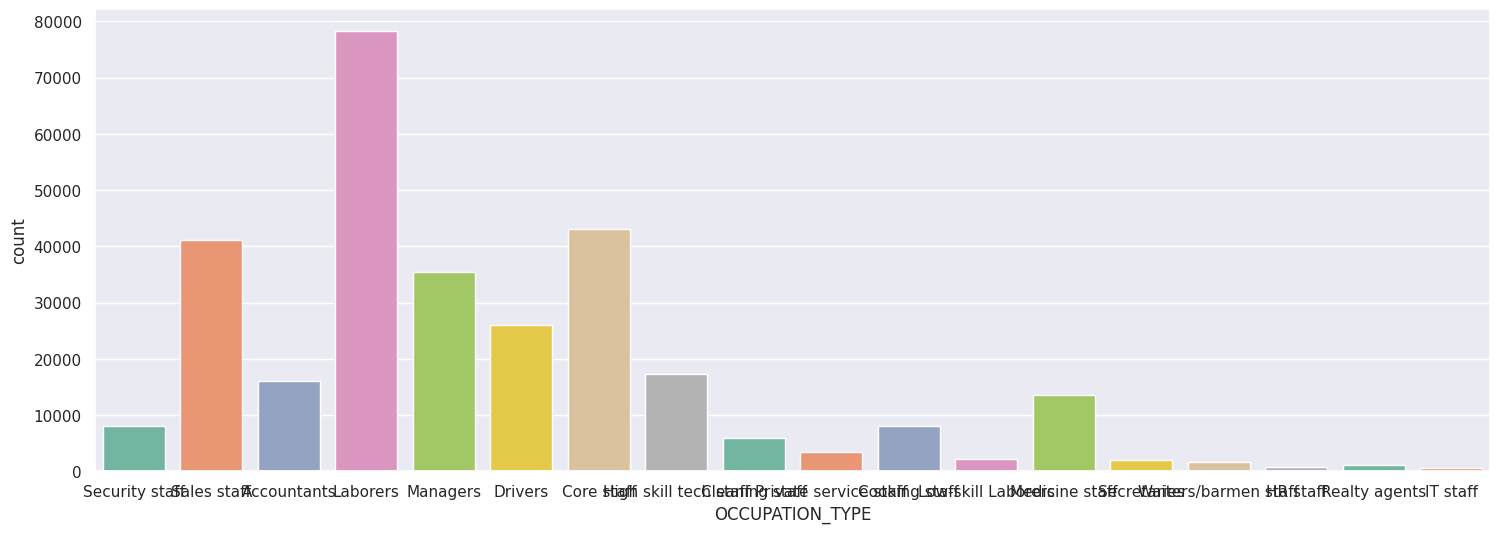

In [107]:
print("Number of people working status:")
print(app['OCCUPATION_TYPE'].value_counts())
sns.set(rc = {'figure.figsize':(18,6)})
sns.countplot(x='OCCUPATION_TYPE', data=app, palette = 'Set2')

<Axes: >

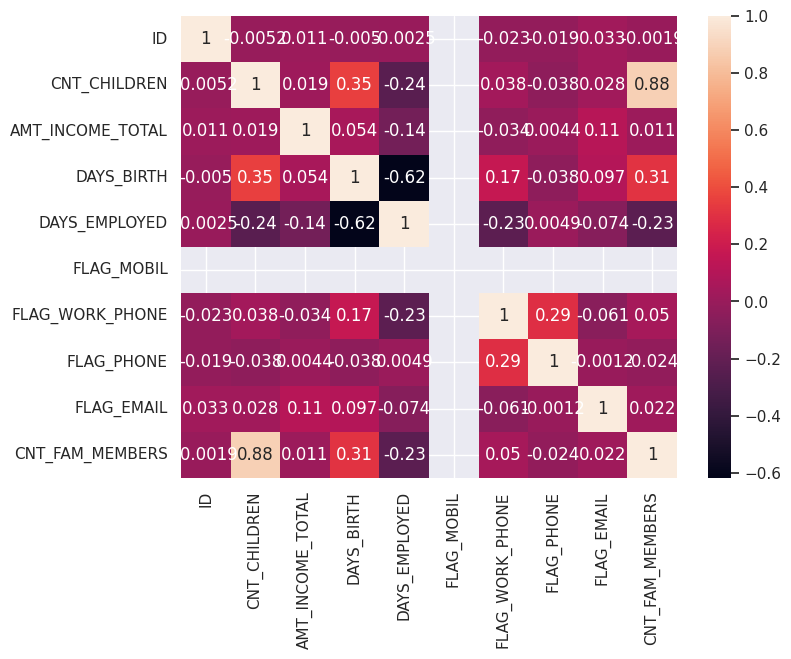

In [108]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(app.corr(numeric_only=True),annot=True)

In [109]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


# Data preprocessing

**1)Duplicate records:-**
Removing duplicate records is an important preprocessing step in the Credit Card Approval Prediction project because each applicant should have a unique Applicant ID. Duplicate records may occur due to repeated data entry, merged files, or system errors, which can affect the accuracy and performance of the machine learning model.

In [110]:
#dropping duplicate rows

app.drop_duplicates(subset=['ID'], inplace=True)

In [111]:
app.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438510 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438510 non-null  int64  
 1   CODE_GENDER          438510 non-null  object 
 2   FLAG_OWN_CAR         438510 non-null  object 
 3   FLAG_OWN_REALTY      438510 non-null  object 
 4   CNT_CHILDREN         438510 non-null  int64  
 5   AMT_INCOME_TOTAL     438510 non-null  float64
 6   NAME_INCOME_TYPE     438510 non-null  object 
 7   NAME_EDUCATION_TYPE  438510 non-null  object 
 8   NAME_FAMILY_STATUS   438510 non-null  object 
 9   NAME_HOUSING_TYPE    438510 non-null  object 
 10  DAYS_BIRTH           438510 non-null  int64  
 11  DAYS_EMPLOYED        438510 non-null  int64  
 12  FLAG_MOBIL           438510 non-null  int64  
 13  FLAG_WORK_PHONE      438510 non-null  int64  
 14  FLAG_PHONE           438510 non-null  int64  
 15  FLAG_EMAIL           4

**2)Missing values:-**

In [112]:
app.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [113]:
app.isnull().mean()

,0
ID,0.00000
CODE_GENDER,0.00000
FLAG_OWN_CAR,0.00000
FLAG_OWN_REALTY,0.00000
CNT_CHILDREN,0.00000
AMT_INCOME_TOTAL,0.00000
NAME_INCOME_TYPE,0.00000
NAME_EDUCATION_TYPE,0.00000
NAME_FAMILY_STATUS,0.00000
NAME_HOUSING_TYPE,0.00000


In this dataset, the occupation type column contains null values, but it is removed during the cleaning process because it is not required for final model training.

After checking the remaining columns, no missing values are found, so further imputation is not required. This process ensures that the dataset is clean, complete, and ready for preprocessing, feature selection, scaling, and machine learning model training.

**3)Data cleaning and merging:-**

In [114]:

def data_cleaning(app, credit):
    # --- 1. CLEANING APPLICANT DATA ---

    # Create family_dependency: combine children and family members
    app['family_dependency'] = app['CNT_CHILDREN'] + app['CNT_FAM_MEMBERS']

    # Handle negative values for time-related features
    app['DAYS_BIRTH'] = abs(app['DAYS_BIRTH'])
    app['DAYS_EMPLOYED'] = abs(app['DAYS_EMPLOYED'])

    # Drop unnecessary columns (Example list)
    cols_to_drop = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
    app.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # Map categorical columns to numerical labels
    # Example mapping for Housing Type
    mapping_dict = {'House / apartment': 0, 'With parents': 1, 'Municipal apartment': 2,
                    'Rented apartment': 3, 'Office apartment': 4, 'Co-op apartment': 5}
    app['NAME_HOUSING_TYPE'] = app['NAME_HOUSING_TYPE'].map(mapping_dict)

    # --- 2. CLEANING AND MERGING CREDIT DATA ---

    # Group by ID to handle multiple records
    # Create new features based on credit history period
    credit['open_month'] = credit.groupby('ID')['MONTHS_BALANCE'].transform('min')
    credit['end_months'] = credit.groupby('ID')['MONTHS_BALANCE'].transform('max')
    credit['window'] = credit['end_months'] - credit['open_month']

    # Interpret STATUS (Example logic: 0-5 are overdue, C/X are good/no records)
    status_map = {'C': 0, 'X': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6}
    credit['STATUS'] = credit['STATUS'].map(status_map)

    # Aggregate credit data by ID before merging with applicant data
    credit_agg = credit.groupby('ID').agg({
        'STATUS': 'max',
        'window': 'first'
    }).reset_index()

    # --- 3. MERGE ---
    final_df = pd.merge(app, credit_agg, on='ID', how='inner')

    return final_df

# Usage:
# cleaned_data = data_cleaning(application_record, credit_record)

In [115]:
final_df = data_cleaning(app,credit)

In [116]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,family_dependency,STATUS,window
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,3,12005,4542,NaN,2.0,2.0,2,15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,3,12005,4542,NaN,2.0,2.0,2,14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,0,21474,1134,Security staff,2.0,2.0,1,29
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,0,19110,3051,Sales staff,1.0,1.0,1,4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,0,19110,3051,Sales staff,1.0,1.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,0,17348,2420,Managers,2.0,2.0,6,11
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,0,12387,1325,Medicine staff,2.0,2.0,6,23
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,0,12387,1325,Medicine staff,2.0,2.0,6,32
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,0,17958,655,Sales staff,2.0,2.0,3,9


The **data_cleaning()** function is used to clean, transform, and prepare the applicant dataset before machine learning model training. Raw datasets may contain unnecessary columns, negative values, inconsistent information, and categorical features that must be converted into a useful format for analysis and prediction.

In this process, a new column is created by combining family members and children information to better represent family dependency. Unnecessary columns are removed to reduce complexity and improve model performance. The **DAYS_BIRTH** and **DAYS_EMPLOYED** columns contain negative values, so the abs() function is used to convert them into positive values for easier interpretation and analysis.

Feature mapping is applied to categorical columns such as housing type, income type, education type, and family type to convert text values into numerical labels suitable for machine learning algorithms. For the credit records dataset, the data is grouped using the ID column to combine multiple monthly records for each applicant. New features such as **open_month, end_months, and window** are created from the MONTHS_BALANCE column to represent the applicant’s credit activity period. The STATUS column is also interpreted to identify payment behavior such as timely payments, overdue payments, and no loan records, which helps improve credit approval prediction accuracy.

**4)Feature Engineering:-**

In [117]:
final_df['STATUS_BIN'] = (final_df['STATUS'] > 1).astype(int)

In [118]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,family_dependency,STATUS,window,STATUS_BIN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,3,12005,4542,NaN,2.0,2.0,2,15,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,3,12005,4542,NaN,2.0,2.0,2,14,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,0,21474,1134,Security staff,2.0,2.0,1,29,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,0,19110,3051,Sales staff,1.0,1.0,1,4,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,0,19110,3051,Sales staff,1.0,1.0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,0,17348,2420,Managers,2.0,2.0,6,11,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,0,12387,1325,Medicine staff,2.0,2.0,6,23,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,0,12387,1325,Medicine staff,2.0,2.0,6,32,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,0,17958,655,Sales staff,2.0,2.0,3,9,1


In [119]:
print("\nMissing values in each column:")
print(final_df.isnull().sum().sort_values(ascending=False))


Missing values in each column:
OCCUPATION_TYPE        11323
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
CNT_CHILDREN               0
FLAG_OWN_REALTY            0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
AMT_INCOME_TOTAL           0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
CNT_FAM_MEMBERS            0
family_dependency          0
STATUS                     0
window                     0
STATUS_BIN                 0
dtype: int64


**5)Handling categorical values:-**

In [120]:
from sklearn.preprocessing import LabelEncoder

cg = LabelEncoder()
oc = LabelEncoder()
own_r = LabelEncoder()
it = LabelEncoder()
et = LabelEncoder()
fs = LabelEncoder()
ht = LabelEncoder()


final_df['CODE_GENDER'] = cg.fit_transform(final_df['CODE_GENDER'])
final_df['FLAG_OWN_CAR'] = oc.fit_transform(final_df['FLAG_OWN_CAR'])
final_df['FLAG_OWN_REALTY'] = own_r.fit_transform(final_df['FLAG_OWN_REALTY'])
final_df['NAME_INCOME_TYPE'] = it.fit_transform(final_df['NAME_INCOME_TYPE'])
final_df['NAME_EDUCATION_TYPE'] = et.fit_transform(final_df['NAME_EDUCATION_TYPE'])
final_df['NAME_FAMILY_STATUS'] = fs.fit_transform(final_df['NAME_FAMILY_STATUS'])
final_df['NAME_HOUSING_TYPE'] = ht.fit_transform(final_df['NAME_HOUSING_TYPE'])

In [121]:
from sklearn.preprocessing import LabelEncoder

# Gender
le = LabelEncoder()
le.fit(app['CODE_GENDER'])
print("CODE_GENDER:", dict(zip(le.classes_, le.transform(le.classes_))))

# Own Car
le = LabelEncoder()
le.fit(app['FLAG_OWN_CAR'])
print("FLAG_OWN_CAR:", dict(zip(le.classes_, le.transform(le.classes_))))

# Own Realty
le = LabelEncoder()
le.fit(app['FLAG_OWN_REALTY'])
print("FLAG_OWN_REALTY:", dict(zip(le.classes_, le.transform(le.classes_))))

# Income Type
le = LabelEncoder()
le.fit(app['NAME_INCOME_TYPE'])
print("NAME_INCOME_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

# Education
le = LabelEncoder()
le.fit(app['NAME_EDUCATION_TYPE'])
print("NAME_EDUCATION_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

# Family Status
le = LabelEncoder()
le.fit(app['NAME_FAMILY_STATUS'])
print("NAME_FAMILY_STATUS:", dict(zip(le.classes_, le.transform(le.classes_))))

# Housing Type
le = LabelEncoder()
le.fit(app['NAME_HOUSING_TYPE'])
print("NAME_HOUSING_TYPE:", dict(zip(le.classes_, le.transform(le.classes_))))

CODE_GENDER: {'F': np.int64(0), 'M': np.int64(1)}
FLAG_OWN_CAR: {'N': np.int64(0), 'Y': np.int64(1)}
FLAG_OWN_REALTY: {'N': np.int64(0), 'Y': np.int64(1)}
NAME_INCOME_TYPE: {'Commercial associate': np.int64(0), 'Pensioner': np.int64(1), 'State servant': np.int64(2), 'Student': np.int64(3), 'Working': np.int64(4)}
NAME_EDUCATION_TYPE: {'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}
NAME_FAMILY_STATUS: {'Civil marriage': np.int64(0), 'Married': np.int64(1), 'Separated': np.int64(2), 'Single / not married': np.int64(3), 'Widow': np.int64(4)}
NAME_HOUSING_TYPE: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}


In [122]:
final_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,family_dependency,STATUS,window,STATUS_BIN
0,5008804,1,1,1,0,427500.0,4,1,0,3,12005,4542,NaN,2.0,2.0,2,15,1
1,5008805,1,1,1,0,427500.0,4,1,0,3,12005,4542,NaN,2.0,2.0,2,14,1
2,5008806,1,1,1,0,112500.0,4,4,1,0,21474,1134,Security staff,2.0,2.0,1,29,0
3,5008808,0,0,1,0,270000.0,0,4,3,0,19110,3051,Sales staff,1.0,1.0,1,4,0
4,5008809,0,0,1,0,270000.0,0,4,3,0,19110,3051,Sales staff,1.0,1.0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,1,1,1,0,315000.0,4,4,1,0,17348,2420,Managers,2.0,2.0,6,11,1
36453,5149834,0,0,1,0,157500.0,0,1,1,0,12387,1325,Medicine staff,2.0,2.0,6,23,1
36454,5149838,0,0,1,0,157500.0,1,1,1,0,12387,1325,Medicine staff,2.0,2.0,6,32,1
36455,5150049,0,0,1,0,283500.0,4,4,1,0,17958,655,Sales staff,2.0,2.0,3,9,1


In [123]:
final_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)

occ = LabelEncoder()
final_df['OCCUPATION_TYPE'] = occ.fit_transform(
    final_df['OCCUPATION_TYPE']
)

/tmp/ipykernel_2604/789898324.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)


In [124]:
final_df.drop(columns=['family_dependency'], inplace=True)

In [125]:
print(final_df.dtypes)

ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
OCCUPATION_TYPE          int64
CNT_FAM_MEMBERS        float64
STATUS                   int64
window                   int64
STATUS_BIN               int64
dtype: object


In [126]:
print(final_df['STATUS_BIN'].value_counts())

STATUS_BIN
0    32166
1     4291
Name: count, dtype: int64


# Model Building

**1)Logistic Regression Model:-**

In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def logistic_reg(X_train, X_test, y_train, y_test):
    """
    Builds, trains, tests, and evaluates a Logistic Regression classification model.
    Accepts pre-split training and testing data (X_train, X_test, y_train, y_test).
    Returns the trained model and its predictions.
    """

    # --- MODEL INITIALIZATION ---
    print("Initializing Logistic Regression classifier...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

    # --- FEATURE SCALING ---
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- MODEL TRAINING ---
    print("Training the Logistic Regression model on training data...")
    lr_model.fit(X_train_scaled, y_train)

    # --- MODEL PREDICTION ---
    print("Generating predictions on the unseen test dataset...")
    y_pred = lr_model.predict(X_test_scaled)

    # --- MODEL EVALUATION ---
    print("\n- Model Evaluation Results")

    # 1. Confusion Matrix: Shows counts of True Positives, True Negatives, False Positives, and False Negatives.
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # 2. Classification Report: Generates precision, recall, f1-score, and support metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # --- OPTIONAL VISUAL REPRESENTATION (Seaborn Heatmap) ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Logistic Regression')
    plt.show()

    return lr_model, scaler, y_pred


**2)Random Forest Model:-**

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

def random_forest(X_train, X_test, y_train, y_test):

    """
    Train and evaluate Random Forest Classifier.
    Returns:
        rf_model
        y_pred
    """

    print("Initializing Random Forest Classifier...")

    rf_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
        oob_score=True
    )

    print("Training Random Forest...")
    rf_model.fit(X_train, y_train)

    print("Generating Predictions...")
    y_pred = rf_model.predict(X_test)

    print("\n" + "="*50)
    print("Random Forest Evaluation")
    print("="*50)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy : {accuracy:.4f}")

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    # Classification Report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # ROC-AUC
    y_prob = rf_model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score : {roc:.4f}")

    # Heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')
    plt.title("Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Feature Importance
    importance = (
        pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': rf_model.feature_importances_
        })
        .sort_values(by='Importance', ascending=False)
    )

    print("Important Features")
    print(importance)
    print(f"\nOut-of-Bag Score : {rf_model.oob_score_:.4f}")

    return rf_model, y_pred, importance

**3)Decision Tree Model:-**

In [129]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

def d_tree(xtrain, xtest, ytrain, ytest):
    # Initialize the model with an equals sign (=) instead of a hyphen (-)
    dt = DecisionTreeClassifier()

    # Train the model
    dt.fit(xtrain, ytrain)

    # Assign predictions using an equals sign (=)
    ypred = dt.predict(xtest)

    # Fix matching quotes for all print statements
    print('***DecisionTreeClassifier***')
    print('Confusion matrix')
    print(confusion_matrix(ytest, ypred))
    print('Classification report')
    print(classification_report(ytest, ypred))


In [130]:
X = final_df.drop(columns=['ID','STATUS','STATUS_BIN'])

# Target
y = final_df['STATUS_BIN']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'window']


In [132]:
print(y_train.value_counts())
print(y_test.value_counts())

STATUS_BIN
0    25732
1     3433
Name: count, dtype: int64
STATUS_BIN
0    6434
1     858
Name: count, dtype: int64


Initializing Logistic Regression classifier...
Training the Logistic Regression model on training data...
Generating predictions on the unseen test dataset...

- Model Evaluation Results
Confusion Matrix:
[[3943 2491]
 [ 408  450]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.61      0.73      6434
           1       0.15      0.52      0.24       858

    accuracy                           0.60      7292
   macro avg       0.53      0.57      0.48      7292
weighted avg       0.82      0.60      0.67      7292



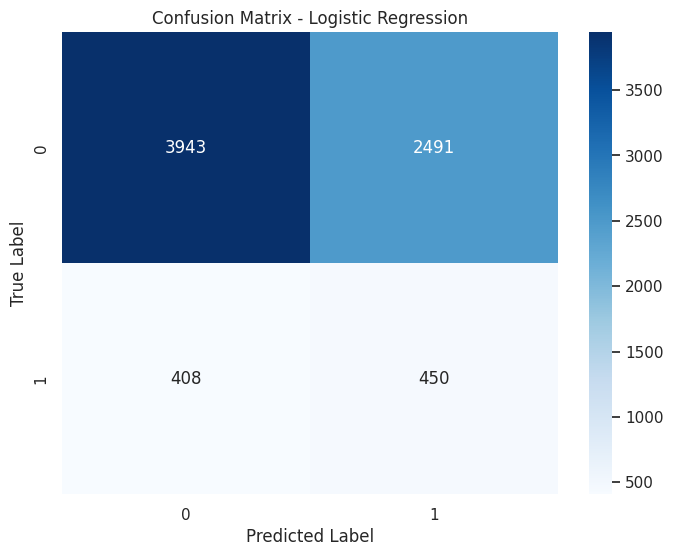

In [133]:
lr_model, scaler, lr_pred = logistic_reg(
    X_train,
    X_test,
    y_train,
    y_test
)

Initializing Random Forest Classifier...
Training Random Forest...
Generating Predictions...

Random Forest Evaluation

Accuracy : 0.8640
Precision : 0.4251
Recall    : 0.4429
F1 Score  : 0.4338

Confusion Matrix
[[5920  514]
 [ 478  380]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      6434
           1       0.43      0.44      0.43       858

    accuracy                           0.86      7292
   macro avg       0.68      0.68      0.68      7292
weighted avg       0.87      0.86      0.87      7292

ROC-AUC Score : 0.7822


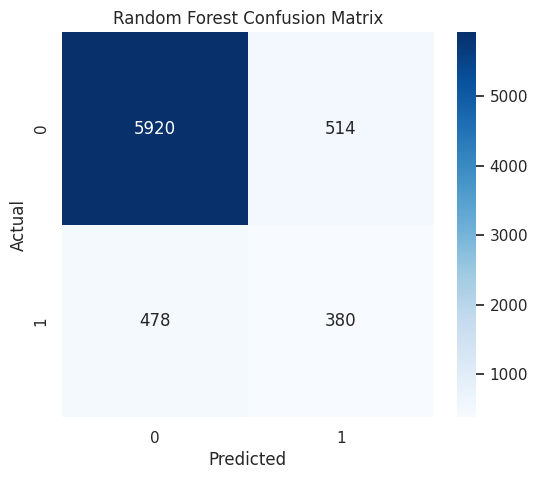

Important Features
                Feature  Importance
13               window    0.223058
9            DAYS_BIRTH    0.182312
10        DAYS_EMPLOYED    0.155032
4      AMT_INCOME_TOTAL    0.126380
11      OCCUPATION_TYPE    0.076975
7    NAME_FAMILY_STATUS    0.034929
5      NAME_INCOME_TYPE    0.032917
12      CNT_FAM_MEMBERS    0.031782
6   NAME_EDUCATION_TYPE    0.030693
3          CNT_CHILDREN    0.023255
1          FLAG_OWN_CAR    0.022692
8     NAME_HOUSING_TYPE    0.021403
2       FLAG_OWN_REALTY    0.020087
0           CODE_GENDER    0.018485

Out-of-Bag Score : 0.8548


In [134]:
rf_model, rf_pred, importance = random_forest(
    X_train,
    X_test,
    y_train,
    y_test
)

In [135]:
d_tree(X_train, X_test, y_train, y_test)

***DecisionTreeClassifier***
Confusion matrix
[[5905  529]
 [ 524  334]]
Classification report
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      6434
           1       0.39      0.39      0.39       858

    accuracy                           0.86      7292
   macro avg       0.65      0.65      0.65      7292
weighted avg       0.86      0.86      0.86      7292



In [137]:
import joblib

joblib.dump(rf_model, "credit_card_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [145]:
# for testing through frontend as an example

approved = final_df[final_df["STATUS_BIN"] == 1].sample(1, random_state=42)

X_sample = approved.drop(columns=["ID", "STATUS", "STATUS_BIN"])

print("Actual:", approved["STATUS_BIN"].values[0])
print("Predicted:", rf_model.predict(X_sample)[0])

print()
print(X_sample)

Actual: 1
Predicted: 1

       CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
32388            0             0                0             0   

       AMT_INCOME_TOTAL  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
32388           54000.0                 1                    1   

       NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
32388                   1                  0       22702         365243   

       OCCUPATION_TYPE  CNT_FAM_MEMBERS  window  
32388               17              2.0      42  


Hence the values to be entered in the form for approval is:- (for ex)
| Field          | Value                          |
| -------------- | ------------------------------ |
| Gender         | Female                         |
| Own Car        | No                             |
| Own Realty     | No                             |
| Children       | 0                              |
| Income         | 54000                          |
| Income Type    | Pensioner                      |
| Education      | Higher Education               |
| Family Status  | Married                        |
| Housing        | House / Apartment              |
| Age            | 62                             |
| Experience     | 40 (ignored because Pensioner) |
| Occupation     | Others                       |
| Family Members | 2                              |
| Credit Window  | 42                             |


In [146]:
# for testing through frontend as an example

approved = final_df[final_df["STATUS_BIN"] == 0].sample(1, random_state=42)

X_sample = approved.drop(columns=["ID", "STATUS", "STATUS_BIN"])

print("Actual:", approved["STATUS_BIN"].values[0])
print("Predicted:", rf_model.predict(X_sample)[0])

print()
print(X_sample)

Actual: 0
Predicted: 0

       CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
32730            0             0                0             1   

       AMT_INCOME_TOTAL  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
32730          157500.0                 4                    1   

       NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
32730                   1                  0       13549           2877   

       OCCUPATION_TYPE  CNT_FAM_MEMBERS  window  
32730                0              3.0      12  


Hence teh values to be entered in the form for rejection (for example) is:-

| Flask Field           | Value                 |
| --------------------- | --------------------- |
| Gender                | Female                |
| Own Car               | No                    |
| Own Realty            | No                    |
| Children              | **1**                 |
| Annual Income         | **157500**            |
| Income Type           | **Working**           |
| Education             | **Higher Education**  |
| Family Status         | **Married**           |
| Housing Type          | **House / Apartment** |
| Age                   | **37**                |
| Experience            | **8**                 |
| Occupation            | **0**                 |
| Family Members        | **3**                 |
| Credit History Window | **12**                |


it is rejected with higher income also beacuse of larger family and shorter credit window than previous example.